In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download NLTK data (sekali aja)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Setting visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#### 1. Load dan Inspect Data

In [2]:
# Load data hasil scraping
df = pd.read_csv('../data_scraping/streaming_reviews.csv')

# Info dasar
print(f"📦 Total reviews: {len(df):,}")
print(f"📋 Kolom: {list(df.columns)}")
print(f"\n📱 Distribusi per aplikasi:")
print(df['app_name'].value_counts())

# Lihat 5 baris pertama
df.head()

📦 Total reviews: 10,000
📋 Kolom: ['app_name', 'username', 'rating', 'review', 'date', 'thumbs_up']

📱 Distribusi per aplikasi:
app_name
Netflix            2000
Vidio              2000
Disney+ Hotstar    2000
WeTV               2000
Viu                2000
Name: count, dtype: int64


,app_name,username,rating,review,date,thumbs_up
0,Netflix,Oliv_mgrthh 29,3,"susah masuk kedalam akun, selalu terlalu banya...",2026-05-26 20:19:03,0
1,Netflix,Fina Nazilia,1,"tidak bisa masuk, harus berbayar dahulu",2026-05-26 20:00:02,0
2,Netflix,Bayu Gustiawan,1,Daftar ae dibikin muter muter,2026-05-26 18:58:22,0
3,Netflix,Luh Gian Adinda,4,"harry potter,please",2026-05-26 17:20:46,0
4,Netflix,Rahma,1,sdah berlangganan dan bayar tpi tiap mau masuk...,2026-05-26 15:52:44,0


🔍 Missing values per kolom:
app_name     0
username     0
rating       0
review       0
date         0
thumbs_up    0
dtype: int64

🔁 Total duplikat: 0

📝 Statistik panjang review:
count    10000.000000
mean        90.969700
std         90.738227
min          1.000000
25%         27.000000
50%         63.500000
75%        123.000000
max        500.000000
Name: review_length, dtype: float64


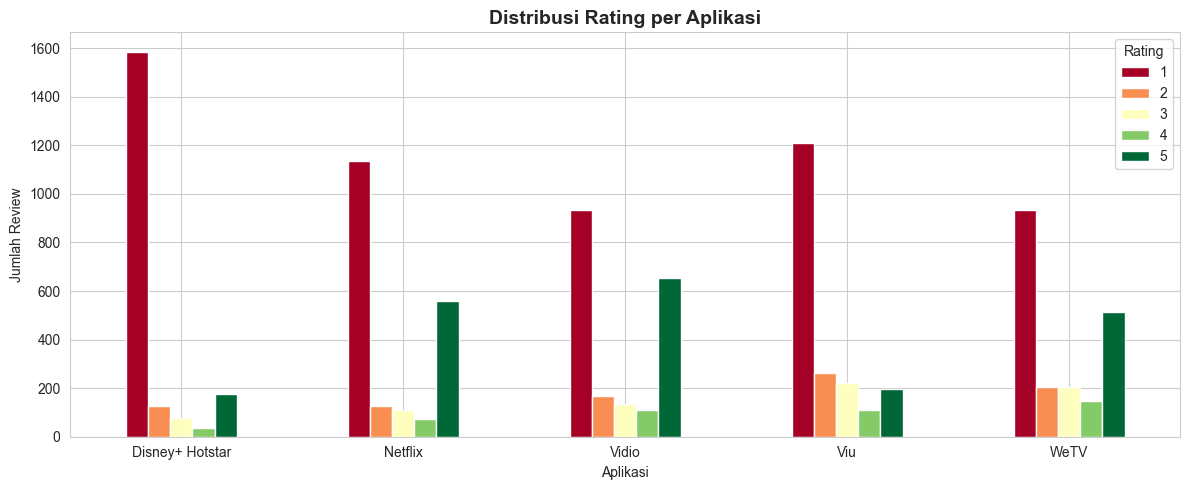

In [3]:
# Cek missing values
print("🔍 Missing values per kolom:")
print(df.isnull().sum())

print("\n🔁 Total duplikat:", df.duplicated().sum())

print("\n📝 Statistik panjang review:")
df['review_length'] = df['review'].astype(str).apply(len)
print(df['review_length'].describe())

# Visualisasi distribusi rating per app
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby(['app_name', 'rating']).size().unstack().plot(
    kind='bar', stacked=False, ax=ax, colormap='RdYlGn'
)
plt.title('Distribusi Rating per Aplikasi', fontsize=14, fontweight='bold')
plt.xlabel('Aplikasi')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

#### 2. Text Cleaning

Membersihkan teks review:
- Hapus baris dengan review kosong
- Lowercase
- Hapus URL, mention, hashtag
- Hapus angka & tanda baca
- Hapus emoji
- Hapus extra whitespace

In [4]:
# Hapus review kosong/null
df = df.dropna(subset=['review'])
df = df[df['review'].astype(str).str.strip() != '']

# Hapus duplikat
df = df.drop_duplicates(subset=['review', 'app_name']).reset_index(drop=True)

print(f"✨ Data setelah cleaning awal: {len(df):,} reviews")

# Function untuk cleaning teks
def clean_text(text):
    text = str(text).lower()                          # Lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)      # Hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)             # Hapus mention/hashtag
    text = re.sub(r'\d+', '', text)                   # Hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)              # Hapus tanda baca
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)        # Hapus emoji/unicode
    text = re.sub(r'\s+', ' ', text).strip()          # Hapus extra whitespace
    return text

# Apply cleaning
df['review_clean'] = df['review'].apply(clean_text)

# Lihat hasil sebelum vs sesudah
print("\n📝 Contoh hasil cleaning:")
df[['review', 'review_clean']].head(5)

✨ Data setelah cleaning awal: 9,397 reviews

📝 Contoh hasil cleaning:


,review,review_clean
0,"susah masuk kedalam akun, selalu terlalu banya...",susah masuk kedalam akun selalu terlalu banyak...
1,"tidak bisa masuk, harus berbayar dahulu",tidak bisa masuk harus berbayar dahulu
2,Daftar ae dibikin muter muter,daftar ae dibikin muter muter
3,"harry potter,please",harry potter please
4,sdah berlangganan dan bayar tpi tiap mau masuk...,sdah berlangganan dan bayar tpi tiap mau masuk...


In [5]:
# Save data hasil cleaning awal dulu
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/reviews_cleaned_step1.csv', index=False)
print(f"💾 Saved: ../data/reviews_cleaned_step1.csv ({len(df):,} rows)")

💾 Saved: ../data/reviews_cleaned_step1.csv (9,397 rows)


#### 3. Normalisasi Slang Bahasa Indonesia

Review di Play Store penuh dengan singkatan & slang seperti:
- `bgt` → `banget`
- `gpp` → `tidak apa-apa`
- `ga` → `tidak`
- `aja` → `saja`
- `udh` → `sudah`

Kalau tidak dinormalisasi, model akan menganggap `bgt` dan `banget` sebagai kata berbeda padahal artinya sama. Ini step **krusial** untuk teks bahasa Indonesia.

In [6]:
# Dictionary slang -> baku (bisa dikembangkan terus)
slang_dict = {
    'bgt': 'banget', 'bnyk': 'banyak', 'gk': 'tidak', 'ga': 'tidak',
    'gak': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'tdk': 'tidak',
    'gpp': 'tidak apa apa', 'gapapa': 'tidak apa apa',
    'udh': 'sudah', 'udah': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'aja': 'saja', 'doang': 'saja',
    'sm': 'sama', 'krn': 'karena', 'krna': 'karena',
    'jg': 'juga', 'jga': 'juga',
    'dgn': 'dengan', 'dg': 'dengan',
    'utk': 'untuk', 'u': 'untuk',
    'yg': 'yang', 'tp': 'tapi', 'tpi': 'tapi',
    'kl': 'kalau', 'klo': 'kalau', 'kalo': 'kalau',
    'gmn': 'bagaimana', 'gimana': 'bagaimana',
    'knp': 'kenapa', 'kenapa': 'kenapa',
    'bs': 'bisa', 'bsa': 'bisa', 'gabisa': 'tidak bisa', 'ga bisa': 'tidak bisa',
    'd': 'di', 'dr': 'dari', 'kpd': 'kepada',
    'org': 'orang', 'orng': 'orang',
    'app': 'aplikasi', 'apk': 'aplikasi', 'aplikasinya': 'aplikasi',
    'film': 'film', 'filmnya': 'film',
    'bagus': 'bagus', 'bgus': 'bagus',
    'jelek': 'jelek', 'jlk': 'jelek',
    'lambat': 'lambat', 'lmbt': 'lambat', 'lemot': 'lambat',
    'cepat': 'cepat', 'cpt': 'cepat', 'cepet': 'cepat',
    'mahal': 'mahal', 'mhl': 'mahal',
    'murah': 'murah', 'mrh': 'murah',
    'parah': 'parah', 'prh': 'parah',
    'mantap': 'mantap', 'mantul': 'mantap', 'mantab': 'mantap',
    'keren': 'keren', 'krn2': 'keren',
    'oke': 'oke', 'ok': 'oke', 'okay': 'oke',
    'thx': 'terima kasih', 'tq': 'terima kasih', 'makasih': 'terima kasih',
    'nonton': 'tonton', 'nntn': 'tonton',
    'login': 'login', 'logout': 'logout',
    'gais': 'teman', 'guys': 'teman', 'gaes': 'teman',
    'banget': 'banget', 'bgt2': 'banget',
    'sih': '', 'kok': '', 'deh': '', 'dong': '', 'lah': '', 'kan': '',
    'wkwk': '', 'wkwkwk': '', 'hehe': '', 'haha': '',
}

def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)

# Apply
df['review_normalized'] = df['review_clean'].apply(normalize_slang)

# Lihat perbandingan
print("📝 Contoh hasil normalisasi:")
df[['review_clean', 'review_normalized']].sample(5, random_state=42)

📝 Contoh hasil normalisasi:


,review_clean,review_normalized
1618,sukaa erorr kaga jelass,sukaa erorr kaga jelass
7937,kebanyakan iklan sampai iklan jadi males nonto...,kebanyakan iklan sampai iklan jadi males tonto...
8648,jelek banget mana banyak iklan,jelek banget mana banyak iklan
4058,parah dari semalem coba kelola akun ga bisa bu...,parah dari semalem coba kelola akun tidak bisa...
3781,first time langganan basic nya cukup memuaskan...,first time langganan basic nya cukup memuaskan...


#### 4. Stopword Removal

Hapus kata-kata umum yang tidak punya makna khusus seperti `yang`, `di`, `dan`, `untuk`, dll. Ini biar model fokus ke kata-kata yang **bermakna** seperti `bagus`, `lambat`, `buffering`.

Kita pakai stopword dari **Sastrawi** + tambahan custom.

In [7]:
# Stopword bahasa Indonesia dari Sastrawi
stopword_factory = StopWordRemoverFactory()
stopwords_id = set(stopword_factory.get_stop_words())

# Tambahan custom stopwords (kata umum di review aplikasi yang tidak informatif)
custom_stopwords = {
    'nya', 'iya', 'aja', 'sih', 'kok', 'deh', 'dong', 'lah', 'kan',
    'yg', 'gw', 'gue', 'lu', 'lo', 'saya', 'aku', 'kamu',
    'jadi', 'biar', 'kayak', 'kaya', 'kya',
}
stopwords_id.update(custom_stopwords)

# Penting: JANGAN buang kata sentiment-laden seperti 'tidak', 'bukan', 'jangan'
# karena ini sangat penting untuk analisis sentimen
sentiment_keepers = {'tidak', 'bukan', 'jangan', 'belum', 'tanpa', 'kurang'}
stopwords_id = stopwords_id - sentiment_keepers

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stopwords_id and len(w) > 1]
    return ' '.join(filtered)

# Apply
df['review_no_stopwords'] = df['review_normalized'].apply(remove_stopwords)

print(f"📚 Total stopwords yang dipakai: {len(stopwords_id)}")
print("\n📝 Contoh hasil stopword removal:")
df[['review_normalized', 'review_no_stopwords']].sample(5, random_state=42)

📚 Total stopwords yang dipakai: 141

📝 Contoh hasil stopword removal:


,review_normalized,review_no_stopwords
1618,sukaa erorr kaga jelass,sukaa erorr kaga jelass
7937,kebanyakan iklan sampai iklan jadi males tonto...,kebanyakan iklan iklan males tonton gada fitur...
8648,jelek banget mana banyak iklan,jelek banget mana banyak iklan
4058,parah dari semalem coba kelola akun tidak bisa...,parah semalem coba kelola akun tidak buat daft...
3781,first time langganan basic nya cukup memuaskan...,first time langganan basic cukup memuaskan mes...


#### 5. Stemming dengan Sastrawi

Stemming = mengubah kata berimbuhan ke kata dasarnya:
- `membeli` → `beli`
- `pembelian` → `beli`
- `dibeli` → `beli`

Ini biar variasi kata yang artinya sama dianggap satu, jadi analisis lebih akurat.

⚠️ **Note:** Stemming agak lambat (~5-10 menit untuk 10.000 review). Sabar ya!

In [8]:
from tqdm import tqdm
tqdm.pandas()

# Inisialisasi stemmer Sastrawi
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Test dulu
print("🧪 Test stemming:")
print(f"  'membeli'   → '{stemmer.stem('membeli')}'")
print(f"  'pembelian' → '{stemmer.stem('pembelian')}'")
print(f"  'kemampuan' → '{stemmer.stem('kemampuan')}'")

# Apply ke seluruh data (ini bagian paling lama)
print("\n⏳ Stemming sedang berjalan, mohon sabar...")
df['review_stemmed'] = df['review_no_stopwords'].progress_apply(stemmer.stem)

print("\n✅ Stemming selesai!")
print("\n📝 Contoh hasil stemming:")
df[['review_no_stopwords', 'review_stemmed']].sample(5, random_state=42)

🧪 Test stemming:
  'membeli'   → 'beli'
  'pembelian' → 'beli'
  'kemampuan' → 'mampu'

⏳ Stemming sedang berjalan, mohon sabar...


100%|██████████| 9397/9397 [11:55<00:00, 13.14it/s] 


✅ Stemming selesai!

📝 Contoh hasil stemming:


,review_no_stopwords,review_stemmed
1618,sukaa erorr kaga jelass,sukaa erorr kaga jelass
7937,kebanyakan iklan iklan males tonton gada fitur...,banyak iklan iklan males tonton gada fitur ski...
8648,jelek banget mana banyak iklan,jelek banget mana banyak iklan
4058,parah semalem coba kelola akun tidak buat daft...,parah semalem coba kelola akun tidak buat daft...
3781,first time langganan basic cukup memuaskan mes...,first time langgan basic cukup muas meski wakt...


#### 6. Final Cleanup & Save

Sebelum save, kita buang baris yang setelah preprocessing jadi kosong (karena semua katanya kebuang oleh stopwords).

In [9]:
# Hapus row yang jadi kosong setelah preprocessing
df_final = df[df['review_stemmed'].str.strip() != ''].copy()
df_final = df_final[df_final['review_stemmed'].str.len() > 3].copy()

# Tambah kolom sentiment_label berdasarkan rating (untuk modeling nanti)
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df_final['sentiment'] = df_final['rating'].apply(rating_to_sentiment)

# Statistik akhir
print(f"📦 Total reviews sebelum preprocessing: {len(df):,}")
print(f"✨ Total reviews setelah preprocessing: {len(df_final):,}")
print(f"❌ Hilang karena kosong: {len(df) - len(df_final):,}")

print("\n📊 Distribusi sentiment:")
print(df_final['sentiment'].value_counts())

print("\n📱 Distribusi sentiment per app:")
print(df_final.groupby(['app_name', 'sentiment']).size().unstack(fill_value=0))

# Save final
df_final.to_csv('../data/reviews_preprocessed.csv', index=False)
print(f"\n💾 Saved: ../data/reviews_preprocessed.csv ({len(df_final):,} rows)")

📦 Total reviews sebelum preprocessing: 9,397
✨ Total reviews setelah preprocessing: 9,305
❌ Hilang karena kosong: 92

📊 Distribusi sentiment:
sentiment
negative    6488
positive    2086
neutral      731
Name: count, dtype: int64

📱 Distribusi sentiment per app:
sentiment        negative  neutral  positive
app_name                                    
Disney+ Hotstar      1673       76       180
Netflix              1214      109       483
Vidio                1084      128       566
Viu                  1401      219       293
WeTV                 1116      199       564

💾 Saved: ../data/reviews_preprocessed.csv (9,305 rows)
